# **Red ART (Adaptive Resonance Theory - Teoría de la Resonancia Adaptativa)**
<a href="https://ibb.co/LDRTytn5"><img src="https://i.ibb.co/Fk3Q1wgV/Gemini-Generated-Image-kh1vnukh1vnukh1v.png" alt="Gemini-Generated-Image-kh1vnukh1vnukh1v" border="0"></a>

Grupo 9 Redes Neuronales
* Juan Andrés Vallejo Rozo - juvallejor@unal.edu.co
* Andrés Felipe Rojas Aguilar - arojasag@unal.edu.co
* Brayan Camilo Rodríguez Diaz - brrodriguezd@unal.edu.co
* Carlos David Ramírez Muñoz - cramirezmun@unal.edu.co

## **INTRODUCCIÓN**

ART (Adaptive Resonance Theory) es una familia de redes neuronales para aprendizaje no supervisado y clustering incremental que resuelve el *dilema plasticidad–estabilidad*:

> **Plasticidad**: aprender nuevos patrones rápidamente.

> **Estabilidad**: no “olvidar” lo ya aprendido (evitar catástrofe de olvido).

La idea central: solo se aprende si el patrón de entrada y una categoría candidata “hacen resonancia” (coinciden lo suficiente). Esa coincidencia se controla con un umbral llamado *vigilancia ($ ρ $)*.

Estas redes también tienen estas ventajas:
- **Creación dinámica de clusters**: no es necesario predefinir el numero de clusters a clasificar
- **Explicabilidad**: Cada categoría genera un "prototipo" (pesos $ W $) que muestra el rango exacto de valores que la definen. A diferencia de las decisiones "caja negra" del deep learning.
- **Aprendizaje Incremental**: Aprende de cada dato nuevo en tiempo real sin necesidad de reentrenar todo el modelo.

## **VARIANTES IMPORTANTES**



* **ART1**: Entradas binarias (0/1). Ideal para reconocimiento de caracteres ópticos, análisis de compras (sí/no) y procesamiento de imágenes en blanco y negro.
* **ART2**: Entradas continuas (más complejo, normalizaciones). Históricamente usado para señales analógicas (radares, acústica), pero hoy está prácticamente obsoleto frente a Fuzzy ART.
* **Fuzzy ART**: Entradas continuas en $ [0, 1] $ usando lógica difusa (muy usada). Es el estándar actual para agrupar datos del mundo real sin etiquetas, como telemetría IoT, finanzas o perfiles médicos.
* **ARTMAP (supervisado)**: ART + mapeo a etiquetas. Conecta redes ART para tareas de clasificación exacta, como diagnóstico médico predictivo, detección de fraude o análisis satelital.



---


## **CONCEPTOS CLAVE**
### **Resonancia**

Cuando llega un patrón $ x $, la red:

1. Calcula qué categoría $ j $ lo representa mejor (*competencia*).

2. Verifica si la coincidencia es suficiente (*test de vigilancia*).

3. Si pasa, aprende (*ajuste de pesos*). Si no pasa, resetea esa categoría y prueba la siguiente.


### **Parámetro de vigilancia $ ρ $ (rho)**

* ρ alto ⇒ categorías más “finas” (más clusters).

* ρ bajo ⇒ categorías más “gruesas” (menos clusters).



---


## **ARQUITECTURA GENERAL ART**

<a href="https://ibb.co/9ktKFrT7"><img src="https://i.ibb.co/Mx6wYCVm/diagram.jpg" alt="diagram" border="0"></a>



#### **Elementos de la arquitectura**

##### **Dos campos o capas principales**:

* $ F_1 $ (Input/Comparación): Los datos entran al sistema. También sirve para comparar con datos ya aprendidos.
* $ F_2 $ (Categorías): neuronas competitivas (cada una representa un cluster). Se activa la neurona que mejor concuerde con los input

#### **Flujos de señales y pesos**:
* Input: El dato que llega al sistema para ser clasificada
* Conexión Bottom-up ($ F_1 → F_2 $): selección (qué categoría gana).
* Conexión Top-down ($ F_2 → F_1 $): prototipo/plantilla (qué espera la categoría).
* Output: La categoría a la que pertenece el dato entrante

#### **Mecanismos de control y vigilancia**
* Unidad de Vigilancia ($ρ$): Actúa como un juez que recibe una señal de comparación (z) desde F1​. Comprueba si la similitud entre la entrada y la plantilla cumple con el umbral de exigencia establecido.
* Señal de Reset (Reinicio): Si el test de vigilancia falla, esta señal inhibe (apaga) la categoría actual en F2​. Esto obliga a la red a buscar una categoría alternativa o a crear una nueva.
* Gain Control (Control de Ganancia): Son mecanismos (Gain 1 y Gain 2) que regulan la sensibilidad de las capas para asegurar que el sistema solo aprenda cuando hay una coincidencia estable entre la entrada y la categoría.

### **Glosario de variables y simbolos**:
* Variables de datos y estructura:
  * Vector de entrada ($ x $)
  * Pesos o Plantilla ($ w $)
  * Índice de Categoría ($ j $)
* Operadores Matemáticos:
  * AND Difuso ($ \wedge $): Es el operador de intersección difusa, que se calcula como el valor mínimo elemento a elemento entre dos vectores: $min(x_i​,w_i​)$.

  $$(x \wedge w)_i = \min(x_i, w_i)$$

  * Norma L1 ($\|\|_1$): Indica el "tamaño" o la suma de los valores absolutos de los elementos de un vector. En el contexto de ART, mide la magnitud de la información presente en el dato o en la categoría.

  $$\|x\|_1 = \sum_i |x_i|$$

* Hiperparámetros:
  * Vigilancia Rho ($ρ$): Es el umbral de tolerancia del sistema, con valores entre 0 y 1. Determina qué tan parecido debe ser un dato a una categoría para ser aceptado: un ρ alto exige mucha precisión, mientras que un ρ bajo permite grupos más generales.
  * Parámetro de Elección ($α$): Es una constante muy pequeña (α>0) que se añade al denominador en la función de elección. Su función es evitar la división por cero y actuar como "desempate", dando prioridad a las categorías que son subconjuntos más específicos del dato.
  * Tasa de Aprendizaje ($β$): Controla la velocidad con la que los pesos de una categoría se actualizan al recibir un nuevo dato.

### **Ciclo de reconocimiento**:
1. **Entrada (Input)**: La capa $ F_1 $ recibe los datos que entran al sistema. Puede incluir preprocesamiento o _Complement Coding_

2. **Elección hacia Adelante (Feedforward choice)**: Una señal viaja de $ F_1 → F_2 $ Cada nodo categoria responde con un nivel de coincidencia a su "plantilla"

3. **Plantilla de Retroalimentación (Feedback Template)**: El nodo categoría ganador envia su "plantilla" devuelta a $ F_1 $

    #### Función de elección (choice)

    Selecciona la categoría candidata $(j)$:

    $$
    T_j(x) =
    \frac{\|x \wedge w_j\|_1}{\alpha + \|w_j\|_1}
    $$

    > $(\alpha > 0)$: evita división por cero y controla competencia.


4. **Test de vigilancia**: $ F_1 $ compara el input original con la plantilla de $ F_2 $, calcula un porcentaje de similitud $ z $ que se envia al test.

    $$
    \frac{\|x \wedge w_j\|_1}{\|x\|_1} \ge \rho
    $$

5. **Reinicio - Aprendizaje**:
    * Si la similitud es mayor o igual que $ ρ $, el sistema entra en _resonancia_. La plantilla de la categoria es reajustada con lo aprendido

    $$
    w_j^{new} =
    \beta (x \wedge w_j^{old}) +
    (1-\beta) w_j^{old}
    $$

    $$
    \beta \in (0,1]
    $$

    > Si $\beta = 1$ se tiene aprendizaje rápido (*fast learning*).

    * Si la similitud es menor que $ ρ $, se regresa al paso 2 para escoger una mejor categoría. Si ninguna categoria es lo suficientemente similar, se crea una categoría nueva

# Experimento del Parámetro de Vigilancia (ρ)

## ¿Qué vamos a explorar?

El **parámetro de vigilancia (ρ)** es el corazón de cualquier red ART.  
Controla **qué tan exigente** es la red al decidir si un nuevo patrón encaja en una categoría existente o necesita una nueva.

| Valor de ρ | Comportamiento |
|---|---|
| **ρ bajo** (≈ 0.1) | Agrupa patrones muy distintos juntos → pocas categorías amplias |
| **ρ alto** (≈ 0.9) | Solo agrupa patrones casi idénticos → muchas categorías específicas |

---
**Flujo del experimento:**
1. Generamos puntos 2D como "patrones de entrada"
2. La red ART Fuzzy los clasifica usando el ρ elegido
3. Con el deslizador, cambias ρ en tiempo real y observas cómo cambian los clusters


## 1️⃣ Importaciones y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans Mono'

ModuleNotFoundError: No module named 'numpy'

## 2️⃣ Implementación de Fuzzy ART

Usamos **Fuzzy ART** porque trabaja con valores continuos (no solo binarios como ART1).  
La idea clave es el **complement coding**: cada entrada `x` se extiende a `[x, 1-x]` para preservar la información de magnitud.

### Fórmulas importantes:
- **Función de elección:** $T_j = \frac{|x \wedge w_j|}{\alpha + |w_j|}$ — qué tan bien encaja el patrón en la categoría j
- **Criterio de vigilancia:** $\frac{|x \wedge w_j|}{|x|} \geq \rho$ — ¿encaja suficientemente bien?
- **Actualización:** $w_j^{new} = \beta(x \wedge w_j^{old}) + (1-\beta)w_j^{old}$

In [ ]:
class FuzzyART:
    """
    Implementación de Fuzzy ART (Carpenter et al., 1991)

    Parámetros
    ----------
    rho   : float  — Parámetro de vigilancia (0 a 1)
    alpha : float  — Parámetro de elección (evita división por cero)
    beta  : float  — Tasa de aprendizaje (0=sin aprendizaje, 1=aprendizaje rápido)
    """
    def __init__(self, rho=0.5, alpha=0.001, beta=1.0):
        self.rho   = rho
        self.alpha = alpha
        self.beta  = beta
        self.weights = []   # Lista de pesos de cada categoría (cajita)

    def _complement_code(self, x):
        """Extiende el vector: [x, 1-x] — duplica la dimensión"""
        return np.concatenate([x, 1.0 - x])

    def _fuzzy_and(self, a, b):
        """AND difuso: mínimo elemento a elemento"""
        return np.minimum(a, b)

    def _choice(self, x, w):
        """Función de elección T_j: qué tan bien encaja x en la categoría con peso w"""
        return np.sum(self._fuzzy_and(x, w)) / (self.alpha + np.sum(w))

    def _match(self, x, w):
        """Función de match M_j: ¿pasa el criterio de vigilancia?"""
        return np.sum(self._fuzzy_and(x, w)) / np.sum(x)

    def predict(self, X):
        """
        Clasifica todos los puntos en X y retorna las etiquetas de categoría.
        Entrena la red en el proceso (aprendizaje online).
        """
        labels = []
        self.weights = []  # Reinicia las categorías

        for x_raw in X:
            x = self._complement_code(x_raw)  # Paso 1: complement coding

            assigned = False

            if len(self.weights) > 0:  # Paso 2: buscar categoría existente
                # Ordenar categorías por función de elección (de mayor a menor)
                scores = [self._choice(x, w) for w in self.weights]
                orden = np.argsort(scores)[::-1]

                for j in orden:
                    # Paso 3: prueba de vigilancia
                    if self._match(x, self.weights[j]) >= self.rho:
                        # ✅ RESONANCIA — actualiza la categoría j
                        w_old = self.weights[j]
                        self.weights[j] = (
                            self.beta * self._fuzzy_and(x, w_old) +
                            (1 - self.beta) * w_old
                        )
                        labels.append(j)
                        assigned = True
                        break

            if not assigned:  # Paso 4: crear nueva categoría
                self.weights.append(x.copy())
                labels.append(len(self.weights) - 1)

        return np.array(labels)

    @property
    def n_categories(self):
        return len(self.weights)

## 3️⃣ Generación de datos de prueba

Usaremos puntos 2D con **distribuciones gaussianas** — 4 grupos bien separados.

> ⚠️ **Nota importante sobre el orden de entrada:**  
> ART es sensible al orden en que llegan los patrones. Si los puntos llegan mezclados aleatoriamente, la red crea muchas categorías pequeñas porque cada punto interrumpe el aprendizaje del grupo anterior.  
> En el demo usamos **orden agrupado** (todos los del Grupo A, luego B, etc.) para que ART pueda consolidar bien las 4 categorías.  
> Prueba `X = X_mezclado` para ver la diferencia — ¡esto es parte del comportamiento real de ART!

In [ ]:
np.random.seed(42)

centros = [
    [0.25, 0.25],  # Grupo A
    [0.75, 0.25],  # Grupo B
    [0.25, 0.75],  # Grupo C
    [0.75, 0.75],  # Grupo D
]

n_por_grupo = 25  # Cantidad de datos por grupo
std = 0.04        # Controlar dispersion de cada grupo

X_list = []
y_true = [] # Etiquetas reales para comparacion

# 1. Generar los grupos fuertemente dispersos
for grupo_id, centro in enumerate(centros):
    puntos = np.random.normal(loc=centro, scale=std, size=(n_por_grupo, 2))
    puntos = np.clip(puntos, 0.01, 0.99)  # Mantener dentro del espacio [0,1]
    X_list.append(puntos)
    y_true.extend([grupo_id]* n_por_grupo)

# 2. Agregar "ruido" (Outliers distribuidos aleatoriamente en todo el espacio)
# Esto es excelente para demostrar cómo ART reacciona a datos anómalos aislandolos en categorías nuevas
n_ruido = 5
ruido = np.random.uniform(low=0.01, high=0.99, size=(n_ruido, 2))
X_list.append(ruido)
y_true.extend([4]* n_ruido) # Grupo 4 = Ruido

X = np.vstack(X_list)
np.random.shuffle(X)  # Mezclar para simular llegada aleatoria de patrones

print(f'✅ Dataset disperso generado: {X.shape[0]} puntos (incluyendo {n_ruido} puntos de ruido)')
print(f'   Rango x: [{X[:,0].min():.2f}, {X[:,0].max():.2f}]')
print(f'   Rango y: [{X[:,1].min():.2f}, {X[:,1].max():.2f}]')

✅ Dataset disperso generado: 105 puntos (incluyendo 5 puntos de ruido)
   Rango x: [0.17, 0.87]
   Rango y: [0.17, 0.90]


## 4️⃣ Visualización estática — Comparativa de 3 valores de ρ

Antes del deslizador, observa cómo cambian los resultados con tres valores distintos:

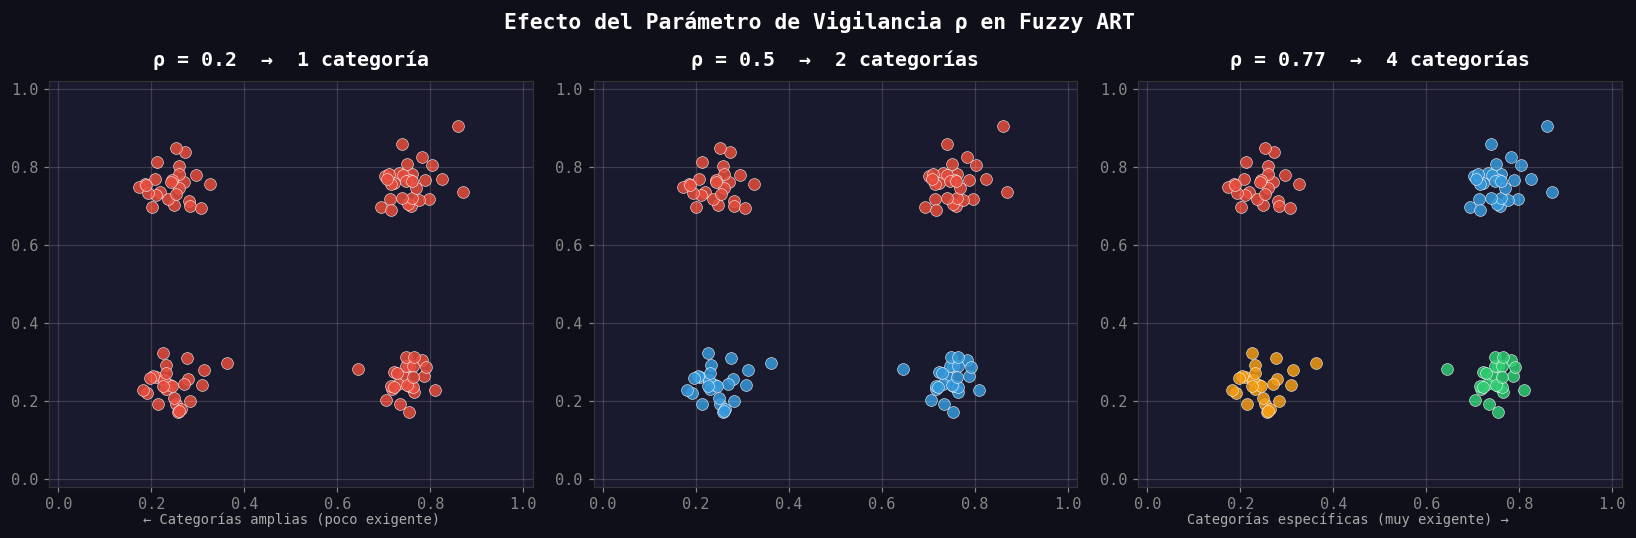

💡 Observa: con ρ bajo se forman pocos grupos; con ρ alto, muchos grupos específicos


In [ ]:
# Paleta de colores para categorías
COLORES = [
    '#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
    '#1abc9c','#e67e22','#34495e','#e91e63','#00bcd4',
    '#8bc34a','#ff5722','#607d8b','#795548','#ffeb3b'
]

rho_valores = [0.2, 0.5, 0.77]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('#0f0f1a')

for ax, rho in zip(axes, rho_valores):
    ax.set_facecolor('#1a1a2e')

    # Entrenar y predecir
    art = FuzzyART(rho=rho)
    labels = art.predict(X)
    n_cats = art.n_categories

    # Dibujar puntos por categoría
    for cat_id in range(n_cats):
        mask = labels == cat_id
        color = COLORES[cat_id % len(COLORES)]
        ax.scatter(
            X[mask, 0], X[mask, 1],
            c=color, s=60, alpha=0.85,
            edgecolors='white', linewidths=0.4,
            label=f'Cat {cat_id}'
        )

    # Estilo del panel
    ax.set_title(
        f'ρ = {rho}  →  {n_cats} categoría{"s" if n_cats != 1 else ""}',
        color='white', fontsize=13, pad=10, fontweight='bold'
    )
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(colors='#888')
    ax.spines[:].set_color('#333')
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.grid(True, alpha=0.15, color='white')

# Etiqueta de interpretación
fig.text(0.18, 0.01, '← Categorías amplias (poco exigente)',
         ha='center', color='#aaa', fontsize=9)
fig.text(0.82, 0.01, 'Categorías específicas (muy exigente) →',
         ha='center', color='#aaa', fontsize=9)
fig.text(0.5, 1.01, 'Efecto del Parámetro de Vigilancia ρ en Fuzzy ART',
         ha='center', color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/art_comparativa.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=130)
plt.show()
print('💡 Observa: con ρ bajo se forman pocos grupos; con ρ alto, muchos grupos específicos')

## 5️⃣ 🎛️ Experimento Interactivo — Deslizador de ρ

Mueve el deslizador y observa en tiempo real cómo la red ART forma más o menos categorías.

In [ ]:
def visualizar_art(rho, mostrar_pesos):
    """
    Función principal de visualización para el deslizador.
    rho           : parámetro de vigilancia
    mostrar_pesos : si True, dibuja el centroide de cada categoría
    """
    clear_output(wait=True)

    # ── Entrenar ART ──────────────────────────────────────────
    art = FuzzyART(rho=rho)
    labels = art.predict(X)
    n_cats = art.n_categories

    # Calcular centroides reales de cada categoría
    centroides = []
    for cat_id in range(n_cats):
        mask = labels == cat_id
        if mask.sum() > 0:
            centroides.append(X[mask].mean(axis=0))
        else:
            centroides.append([np.nan, np.nan])

    # ── Layout de la figura ───────────────────────────────────
    fig, (ax_main, ax_bar) = plt.subplots(
        1, 2, figsize=(13, 5.5),
        gridspec_kw={'width_ratios': [3, 1]}
    )
    fig.patch.set_facecolor('#0d1117')

    # ── Panel principal: scatter de puntos ────────────────────
    ax_main.set_facecolor('#161b22')

    tamaños_cat = []  # Para el gráfico de barras

    for cat_id in range(n_cats):
        mask = labels == cat_id
        n_puntos = mask.sum()
        tamaños_cat.append(n_puntos)
        color = COLORES[cat_id % len(COLORES)]

        ax_main.scatter(
            X[mask, 0], X[mask, 1],
            c=color, s=55, alpha=0.80,
            edgecolors='white', linewidths=0.3,
            zorder=3
        )

        # Dibuja centroide con símbolo especial
        if mostrar_pesos and not np.isnan(centroides[cat_id][0]):
            cx, cy = centroides[cat_id]
            ax_main.scatter(
                cx, cy, marker='*', s=280,
                c=color, edgecolors='white', linewidths=1.2,
                zorder=5
            )
            ax_main.annotate(
                f' C{cat_id}', (cx, cy),
                color='white', fontsize=7.5, fontweight='bold',
                zorder=6
            )

    # Estilo eje principal
    ax_main.set_xlim(-0.03, 1.03)
    ax_main.set_ylim(-0.03, 1.03)
    ax_main.set_xlabel('Dimensión 1', color='#8b949e')
    ax_main.set_ylabel('Dimensión 2', color='#8b949e')
    ax_main.tick_params(colors='#8b949e')
    for spine in ax_main.spines.values():
        spine.set_color('#30363d')
    ax_main.grid(True, alpha=0.1, color='white', linestyle='--')

    # ── Barra de vigilancia visual ────────────────────────────
    barra_color = plt.cm.RdYlGn(rho)  # rojo=bajo, verde=alto

    # Gradiente de fondo para la barra
    grad = np.linspace(0, 1, 100).reshape(-1, 1)
    ax_main.imshow(
        np.zeros((1, 1)), aspect='auto',
        extent=[-0.03, 1.03, -0.03, -0.01],
        alpha=0  # invisible, solo por compatibilidad
    )

    # Título dinámico con interpretación
    if rho < 0.35:
        descripcion = 'PERMISIVO — agrupa patrones muy diferentes'
    elif rho < 0.65:
        descripcion = 'MODERADO — balance entre amplitud y especificidad'
    else:
        descripcion = 'ESTRICTO — solo agrupa patrones casi idénticos'

    ax_main.set_title(
        f'ρ = {rho:.2f}   →   {n_cats} categoría{"s" if n_cats != 1 else ""}   |   {descripcion}',
        color='white', fontsize=11, pad=12, fontweight='bold'
    )

    # ── Panel de barras: tamaño de cada categoría ─────────────
    ax_bar.set_facecolor('#161b22')

    if tamaños_cat:
        colores_bar = [COLORES[i % len(COLORES)] for i in range(n_cats)]
        bars = ax_bar.barh(
            range(n_cats), tamaños_cat,
            color=colores_bar, edgecolor='none',
            height=0.6
        )
        # Etiquetas de cantidad
        for i, (bar, tam) in enumerate(zip(bars, tamaños_cat)):
            ax_bar.text(
                tam + 0.3, i, str(tam),
                va='center', color='white', fontsize=7.5
            )

        ax_bar.set_yticks(range(n_cats))
        ax_bar.set_yticklabels([f'Cat {i}' for i in range(n_cats)],
                                color='#8b949e', fontsize=7.5)
        ax_bar.set_xlabel('Nº de puntos', color='#8b949e', fontsize=9)
        ax_bar.set_xlim(0, max(tamaños_cat) * 1.25)

    ax_bar.set_title('Tamaño de\ncategorías', color='white', fontsize=9)
    ax_bar.tick_params(colors='#8b949e')
    for spine in ax_bar.spines.values():
        spine.set_color('#30363d')
    ax_bar.grid(True, alpha=0.1, color='white', axis='x')

    # ── Pie de figura ─────────────────────────────────────────
    fig.text(
        0.5, -0.02,
        f'Total patrones: {len(X)}   |   Dimensiones: 2   |   '
        f'Categorías creadas: {n_cats}   |   '
        f'Promedio puntos/categoría: {len(X)/n_cats:.1f}',
        ha='center', color='#8b949e', fontsize=8.5
    )

    plt.tight_layout()
    plt.show()

# ── Controles interactivos ────────────────────────────────────
slider_rho = widgets.FloatSlider(
    value=0.5,
    min=0.05, max=0.99, step=0.01,
    description='ρ (vigilancia):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='520px'),
    continuous_update=True,
    readout_format='.2f',
)

toggle_pesos = widgets.ToggleButton(
    value=True,
    description='⭐ Mostrar centroides',
    button_style='info',
    layout=widgets.Layout(width='180px')
)

# Botones de valores predefinidos
btn_bajo  = widgets.Button(description='ρ = 0.20 (amplio)',   button_style='danger',  layout=widgets.Layout(width='150px'))
btn_medio = widgets.Button(description='ρ = 0.50 (medio)',    button_style='warning', layout=widgets.Layout(width='150px'))
btn_alto  = widgets.Button(description='ρ = 0.85 (estricto)', button_style='success', layout=widgets.Layout(width='150px'))

def set_rho_bajo(b):  slider_rho.value = 0.20
def set_rho_medio(b): slider_rho.value = 0.50
def set_rho_alto(b):  slider_rho.value = 0.85

btn_bajo.on_click(set_rho_bajo)
btn_medio.on_click(set_rho_medio)
btn_alto.on_click(set_rho_alto)

controles = widgets.VBox([
    widgets.HTML('<b style="color:#58a6ff; font-size:14px">🎛️ Controles del experimento</b>'),
    widgets.HBox([slider_rho, toggle_pesos]),
    widgets.HBox([btn_bajo, btn_medio, btn_alto]),
    widgets.HTML('<i style="color:#8b949e; font-size:11px">💡 Tip: Mueve el deslizador lentamente para ver cómo aparecen y desaparecen categorías</i>')
])

salida = widgets.interactive_output(
    visualizar_art,
    {'rho': slider_rho, 'mostrar_pesos': toggle_pesos}
)

display(controles, salida)

Output()

## 6️⃣ Análisis: Número de categorías vs ρ

Veamos la curva completa del comportamiento de ART para todos los valores de ρ:

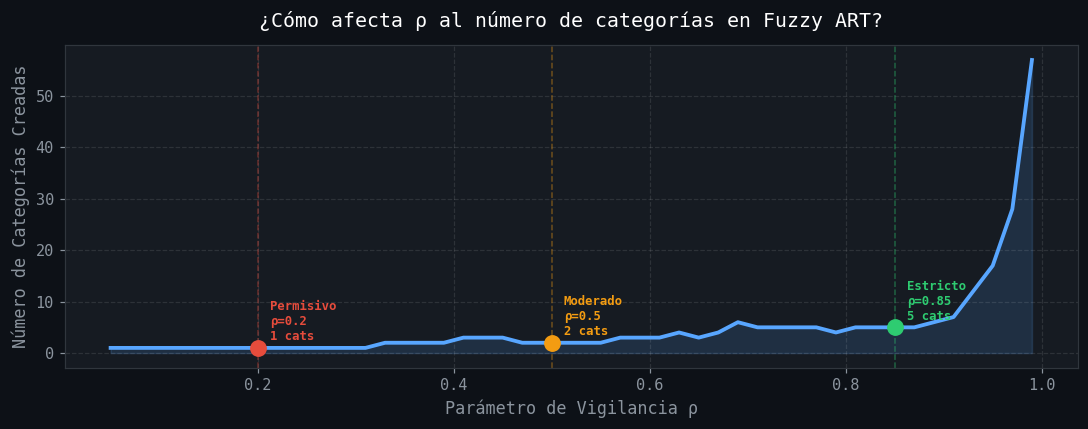

Con ρ=0.05: 1 categorías mínimas
Con ρ=0.99: hasta 57 categorías posibles


In [ ]:
rhos = np.arange(0.05, 1.00, 0.02)
n_categorias = []

for r in rhos:
    art = FuzzyART(rho=r)
    art.predict(X)
    n_categorias.append(art.n_categories)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

# Relleno bajo la curva por zonas
ax.fill_between(rhos, n_categorias, alpha=0.15, color='#58a6ff')
ax.plot(rhos, n_categorias, color='#58a6ff', linewidth=2.5, zorder=3)

# Marcadores de los 3 valores demo
for r_demo, nombre, color in [(0.20,'Permisivo','#e74c3c'),
                               (0.50,'Moderado','#f39c12'),
                               (0.85,'Estricto','#2ecc71')]:
    art_tmp = FuzzyART(rho=r_demo)
    art_tmp.predict(X)
    n = art_tmp.n_categories
    ax.axvline(r_demo, color=color, alpha=0.4, linestyle='--', linewidth=1)
    ax.scatter(r_demo, n, color=color, s=100, zorder=5)
    ax.annotate(f'{nombre}\nρ={r_demo}\n{n} cats',
                (r_demo, n), xytext=(8, 5),
                textcoords='offset points',
                color=color, fontsize=8, fontweight='bold')

ax.set_xlabel('Parámetro de Vigilancia ρ', color='#8b949e', fontsize=11)
ax.set_ylabel('Número de Categorías Creadas', color='#8b949e', fontsize=11)
ax.set_title('¿Cómo afecta ρ al número de categorías en Fuzzy ART?',
             color='white', fontsize=13, pad=12)
ax.tick_params(colors='#8b949e')
for spine in ax.spines.values():
    spine.set_color('#30363d')
ax.grid(True, alpha=0.1, color='white', linestyle='--')

plt.tight_layout()
plt.savefig('/tmp/art_curva_rho.png', bbox_inches='tight',
            facecolor=fig.get_facecolor(), dpi=130)
plt.show()

art_min = FuzzyART(rho=0.05)
art_min.predict(X)
print(f'Con ρ=0.05: {art_min.n_categories} categorías mínimas')
print(f'Con ρ=0.99: hasta {max(n_categorias)} categorías posibles')

## 📝 Resumen del experimento

| Concepto | Lo que observamos |
|---|---|
| **ρ bajo (0.05–0.35)** | Pocas categorías amplias — ART es permisiva y agrupa patrones distintos |
| **ρ medio (0.35–0.65)** | Número de categorías cercano al número de grupos reales (4) |
| **ρ alto (0.65–0.99)** | Muchas categorías pequeñas — ART es estricta, casi una categoría por punto |
| **Resonancia** | Cuando un patrón pasa la prueba de vigilancia → actualiza sin olvidar lo anterior |
| **Nueva categoría** | Cuando ninguna categoría pasa la vigilancia → se crea automáticamente |

### 🔑 La clave de ART:
> El aprendizaje de nuevas categorías **nunca destruye** las categorías existentes.  
> Esto resuelve el **dilema plasticidad-estabilidad** que afecta a las redes tradicionales.

## **Referencias**
- Understanding ART1: A Deep Dive into Adaptive Resonance Theory for Binary Clustering - Aly Alsayed https://medium.com/@alyalsayed/understanding-art1-a-deep-dive-into-adaptive-resonance-theory-for-binary-clustering-11fe675e1939
- ART-1 & ART-2 Network, Stability-Plasticity (Lecture-12 on Neural Network and Fuzzy Logic Control) - Sudip Mandal https://youtu.be/TymKJZWLyXU?si=lyPYOaFRVARUQeXI
- ADAPTIVE RESONANCE THEORY (ART) from ML by Dr. A. R. Mohamed Shanavas https://youtu.be/h8d0Ys0vOfg?si=wF-vjyHb4DPymbBM